# **Notebook 3: Model Comparison, Optimisation & Explainability**
## Capstone: Customer Satisfaction Analysis for the Olist Brazilian E-Commerce Marketplace
---

### 📋 TO-DO: Before Running This Notebook

**What you NEED (created by Notebook 2):**
- [ ] `olist_train_model.csv` / `olist_test_model.csv` — leakage-safe feature sets (same features for every model)
- [ ] `baseline_metrics.csv` — the logistic regression benchmark to beat

**What this notebook will CREATE:**
- [ ] `model_comparison.csv` — metrics for every model incl. the baseline
- [ ] `prediction_output.csv` — final per-order predictions + probabilities _(Stage 4 deliverable, for Tableau/Power BI)_

> This is the most technical stage: train several advanced models, compare them **with cross-validation**,
> tune the winner, **explain** it with SHAP and LIME, and export predictions for the dashboard.
---

In [ ]:
# pandas/numpy/scikit-learn/matplotlib/seaborn are pre-installed in Colab; only these extras are missing.
# (Avoid `-U` on numpy/pandas in Colab.)
!pip install -q lightgbm xgboost shap lime

## Setup

In [2]:
import sys
print("Python version:", sys.version)

packages = [
    "lightgbm",
    "xgboost",
    "shap",
    "lime"
]

for package in packages:
    try:
        module = __import__(package)
        version = getattr(module, "__version__", "version not available")
        print(f"✓ {package}: {version}")
    except Exception as e:
        print(f"✗ {package}: {e}")

Python version: 3.11.15 | packaged by conda-forge | (main, Aug 11 2026, 10:17:41) [MSC v.1944 64 bit (AMD64)]
✓ lightgbm: 4.6.0
✓ xgboost: 3.2.0
✓ shap: 0.47.2
✓ lime: version not available


In [3]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\Niroj\anaconda3\envs\olist_capstone\python.exe
3.11.15 | packaged by conda-forge | (main, Aug 11 2026, 10:17:41) [MSC v.1944 64 bit (AMD64)]


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             RocCurveDisplay, ConfusionMatrixDisplay)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 80)
RANDOM_STATE = 42
sns.set_style("whitegrid")

In [5]:
# Load the leakage-safe model data and the baseline benchmark from Notebook 2
# YOUR CODE HERE

# Load leakage-safe train/test data
train_df = pd.read_csv("olist_train_model.csv")
test_df = pd.read_csv("olist_test_model.csv")

# Load Logistic Regression baseline benchmark
baseline_df = pd.read_csv("baseline_metrics.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("\nBaseline metrics:")
display(baseline_df)

Train shape: (76659, 33)
Test shape : (19165, 33)

Baseline metrics:


,model,accuracy,precision,recall,f1_macro,roc_auc,unsatisfied_recall
0,Logistic Regression,0.727211,0.85351,0.789978,0.626189,0.691895,0.492075


## **Stage 3: Model Comparison & Optimisation**

### **Task 3.1 — Build and Compare Advanced Models [7 Marks]**
**The Task:** Train at least three advanced models and compare them — together with the Stage 2 baseline —
in one structured metrics table.

**Hints & Tips:**
* Train **Random Forest**, **LightGBM**, and **XGBoost** (tree models need no scaling).
* Handle imbalance: `class_weight="balanced"` (RF/LightGBM) or `scale_pos_weight = neg/pos` (XGBoost).
* Keep a logistic regression (scaled) in the table so the baseline is directly comparable.

**🧠 Learner Inference:** Tree ensembles usually win here because the delivery/freight signal is non-linear
and interacts (e.g., "late AND high freight").

In [7]:
# imbalance ratio for XGBoost [1 mark]
# YOUR CODE HERE

# XGBoost will treat UNSATISFIED as the positive class (1)
# (label flip happens later, after the train/test split — see y_train_xgb / y_test_xgb)

n_satisfied = (train_df["satisfied"] == 1).sum()
n_unsatisfied = (train_df["satisfied"] == 0).sum()

scale_pos_weight = n_satisfied / n_unsatisfied

print("Satisfied orders  :", n_satisfied)
print("Unsatisfied orders:", n_unsatisfied)
print("XGBoost scale_pos_weight:", round(scale_pos_weight, 3))

Satisfied orders  : 60507
Unsatisfied orders: 16152
XGBoost scale_pos_weight: 3.746


In [8]:
# scaled copy for the linear model only and setting up advanced models [2 marks]
# YOUR CODE HERE

# Target
y_train = train_df["satisfied"].astype(int)
y_test = test_df["satisfied"].astype(int)

# Columns that are NOT model features
# These are retained in the exported files for later prediction/dashboard use.
metadata_cols = [
    "satisfied",
    "order_id",
    "customer_id",
    "seller_id",
    "customer_state",
    "product_category_name_english",
    "dominant_payment_type"
]

# Keep only numeric model-ready features
feature_cols = [
    col for col in train_df.columns
    if col not in metadata_cols
    and pd.api.types.is_numeric_dtype(train_df[col])
]

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

print("Number of model features:", len(feature_cols))
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# Scale ONLY for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

print("\nModels prepared:")
for name in models:
    print("✓", name)

Number of model features: 25
X_train: (76659, 25)
X_test : (19165, 25)

Models prepared:
✓ Logistic Regression
✓ Random Forest
✓ LightGBM
✓ XGBoost


In [9]:
y_train_xgb = 1 - y_train
y_test_xgb = 1 - y_test

In [11]:
# model comparison [4 marks]
# YOUR CODE HERE

results = []

# Logistic Regression
print("Training Logistic Regression...")
logreg = models["Logistic Regression"]
logreg.fit(X_train_scaled, y_train)
pred = logreg.predict(X_test_scaled)
prob = logreg.predict_proba(X_test_scaled)[:, 1]
results.append({
    "model": "Logistic Regression",
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred),
    "recall": recall_score(y_test, pred),
    "f1_macro": f1_score(y_test, pred, average="macro"),
    "roc_auc": roc_auc_score(y_test, prob)
})

# Random Forest
print("Training Random Forest...")
rf = models["Random Forest"]
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
prob = rf.predict_proba(X_test)[:, 1]
results.append({
    "model": "Random Forest",
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred),
    "recall": recall_score(y_test, pred),
    "f1_macro": f1_score(y_test, pred, average="macro"),
    "roc_auc": roc_auc_score(y_test, prob)
})

# LightGBM
print("Training LightGBM...")
lgbm = models["LightGBM"]
lgbm.fit(X_train, y_train)
pred = lgbm.predict(X_test)
prob = lgbm.predict_proba(X_test)[:, 1]
results.append({
    "model": "LightGBM",
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred),
    "recall": recall_score(y_test, pred),
    "f1_macro": f1_score(y_test, pred, average="macro"),
    "roc_auc": roc_auc_score(y_test, prob)
})

# XGBoost
print("Training XGBoost...")
xgb_model = models["XGBoost"]  # renamed from `xgb` to avoid shadowing the xgboost module later

# Make UNSATISFIED the positive class for XGBoost
y_train_xgb = 1 - y_train
y_test_xgb = 1 - y_test

xgb_model.fit(X_train, y_train_xgb)

# Probability of unsatisfied
prob_unsatisfied = xgb_model.predict_proba(X_test)[:, 1]

# Convert predictions back to original target:
# XGBoost 1 = unsatisfied → original 0
pred_xgb = (prob_unsatisfied >= 0.5).astype(int)
pred = 1 - pred_xgb

# Probability of original satisfied class
prob = 1 - prob_unsatisfied

results.append({
    "model": "XGBoost",
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred),
    "recall": recall_score(y_test, pred),
    "f1_macro": f1_score(y_test, pred, average="macro"),
    "roc_auc": roc_auc_score(y_test, prob)
})

# -----------------------------
# Add Notebook 2 baseline
# -----------------------------
baseline_row = baseline_df.iloc[0]
results.append({
    "model": "Logistic Regression (Stage 2 Baseline)",
    "accuracy": baseline_row["accuracy"],
    "precision": baseline_row["precision"],
    "recall": baseline_row["recall"],
    "f1_macro": baseline_row["f1_macro"],
    "roc_auc": baseline_row["roc_auc"]
})

# Results table
model_comparison = pd.DataFrame(results)
model_comparison = model_comparison.sort_values(
    "f1_macro",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)
display(
    model_comparison.style.format({
        "accuracy": "{:.4f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1_macro": "{:.4f}",
        "roc_auc": "{:.4f}"
    })
)

Training Logistic Regression...
Training Random Forest...
Training LightGBM...
Training XGBoost...

MODEL COMPARISON


,model,accuracy,precision,recall,f1_macro,roc_auc
0,Random Forest,0.8111,0.8352,0.9476,0.6442,0.7001
1,XGBoost,0.7393,0.8566,0.8043,0.6372,0.7048
2,LightGBM,0.7362,0.8566,0.7997,0.6353,0.7057
3,Logistic Regression,0.7272,0.8535,0.7900,0.6262,0.6919
4,Logistic Regression (Stage 2 Baseline),0.7272,0.8535,0.7900,0.6262,0.6919


In [29]:
model_comparison.to_csv("model_comparison.csv", index=False)
print("Saved: model_comparison.csv")

Saved: model_comparison.csv


### **Task 3.2 — Model-Selection Best Practices [6 Marks]**
**The Task:** Use **stratified cross-validation** for a fair comparison, check the **bias–variance**
behaviour (train vs CV), then select a final model with justification.

**🧠 Learner Inference:** A single split can flatter one model by luck; CV gives a mean ± std you can trust.

In [12]:
# Remove the target from the feature list
# (using feature_cols from Task 3.1 setup — numeric_cols was never defined)
X_cv = train_df[feature_cols].copy()
y_cv = train_df["satisfied"].copy()

print("X_cv shape:", X_cv.shape)
print("y_cv shape:", y_cv.shape)

print("\nNon-numeric columns:")
print(X_cv.select_dtypes(exclude="number").columns.tolist())

print("\nMissing values in X_cv:", X_cv.isna().sum().sum())
print("Missing values in y_cv:", y_cv.isna().sum())

X_cv shape: (76659, 25)
y_cv shape: (76659,)

Non-numeric columns:
[]

Missing values in X_cv: 0
Missing values in y_cv: 0


In [13]:
# ---- Stratified 5-fold CV (ROC-AUC) on the FULL feature matrix --- [3 marks]
# YOUR CODE HERE
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Fresh XGBoost for CV: y_cv has satisfied=1 as positive class,
# so scale_pos_weight must invert compared to xgb_model (which was tuned for unsatisfied=1)
xgb_cv = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1 / scale_pos_weight,   # inverted: satisfied is now the positive class
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

models_for_cv = {
    "Random Forest": rf,
    "LightGBM": lgbm,
    "XGBoost": xgb_cv
}

cv_results = []

for name, model in models_for_cv.items():
    print(f"Running 5-fold CV for {name}...")

    scores = cross_validate(
        model,
        X_cv,
        y_cv,
        cv=cv,
        scoring="roc_auc",
        return_train_score=True,
        n_jobs=1
    )

    cv_results.append({
        "model": name,
        "train_roc_auc_mean": scores["train_score"].mean(),
        "train_roc_auc_std": scores["train_score"].std(),
        "cv_roc_auc_mean": scores["test_score"].mean(),
        "cv_roc_auc_std": scores["test_score"].std(),
        "train_cv_gap": (
            scores["train_score"].mean()
            - scores["test_score"].mean()
        )
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values(
    "cv_roc_auc_mean",
    ascending=False
).reset_index(drop=True)

print("\n" + "=" * 70)
print("STRATIFIED 5-FOLD CROSS-VALIDATION")
print("=" * 70)
display(cv_results_df.round(4))


Running 5-fold CV for Random Forest...
Running 5-fold CV for LightGBM...
Running 5-fold CV for XGBoost...

STRATIFIED 5-FOLD CROSS-VALIDATION


,model,train_roc_auc_mean,train_roc_auc_std,cv_roc_auc_mean,cv_roc_auc_std,train_cv_gap
0,XGBoost,0.8361,0.0018,0.7094,0.0062,0.1266
1,LightGBM,0.8264,0.0013,0.7084,0.0061,0.1180
2,Random Forest,1.0000,0.0000,0.7070,0.0065,0.2930


In [14]:
# ---- Select the final model among the TREE candidates (needed for SHAP TreeExplainer) --- [1 mark]
# YOUR CODE HERE

final_model = xgb_cv          # the CV-oriented XGBoost — matches y_cv's label direction (satisfied=1)
final_model_name = "XGBoost"

# Pull the actual CV numbers from the results table rather than hardcoding
xgb_cv_row = cv_results_df[cv_results_df["model"] == "XGBoost"].iloc[0]

print("=" * 60)
print("FINAL TREE MODEL SELECTION")
print("=" * 60)
print("Selected model :", final_model_name)
print("CV ROC-AUC     :", round(xgb_cv_row["cv_roc_auc_mean"], 4))
print("CV ROC-AUC std :", round(xgb_cv_row["cv_roc_auc_std"], 4))

print("\n✓ XGBoost selected because it achieved the highest")
print("  mean 5-fold CV ROC-AUC among the tree models.")

FINAL TREE MODEL SELECTION
Selected model : XGBoost
CV ROC-AUC     : 0.7094
CV ROC-AUC std : 0.0062

✓ XGBoost selected because it achieved the highest
  mean 5-fold CV ROC-AUC among the tree models.


In [15]:
# bias-variance: train vs test AUC gap for the chosen model [2 marks]
# YOUR CODE HERE
from sklearn.metrics import roc_auc_score

# Train the selected XGBoost model on the complete training set
final_model.fit(X_cv, y_cv)

# Training probabilities
train_proba = final_model.predict_proba(X_cv)[:, 1]

# Test probabilities
X_test_cv = test_df[X_cv.columns]
y_test_cv = test_df["satisfied"]

test_proba = final_model.predict_proba(X_test_cv)[:, 1]

# ROC-AUC
train_auc = roc_auc_score(y_cv, train_proba)
test_auc = roc_auc_score(y_test_cv, test_proba)

auc_gap = train_auc - test_auc

print("=" * 60)
print("BIAS–VARIANCE CHECK — FINAL MODEL")
print("=" * 60)

print(f"Final model       : {final_model_name}")
print(f"Training ROC-AUC  : {train_auc:.4f}")
print(f"Test ROC-AUC      : {test_auc:.4f}")
print(f"Train-Test gap    : {auc_gap:.4f}")

if auc_gap < 0.03:
    print("\nInterpretation: Small gap → good generalisation.")
elif auc_gap < 0.08:
    print("\nInterpretation: Moderate gap → some variance, but acceptable.")
else:
    print("\nInterpretation: Large gap → evidence of overfitting/high variance.")

BIAS–VARIANCE CHECK — FINAL MODEL
Final model       : XGBoost
Training ROC-AUC  : 0.8176
Test ROC-AUC      : 0.7056
Train-Test gap    : 0.1120

Interpretation: Large gap → evidence of overfitting/high variance.


### Give justification for final model selection.

##### XGBoost was selected as the final tree candidate because it achieved the highest mean stratified 5-fold CV ROC-AUC of 0.7094, outperforming LightGBM (0.7084) and Random Forest (0.7070). Random Forest showed substantial overfitting, with a train–CV gap of 0.2930 compared with 0.1266 for XGBoost.

### **Task 3.3 — Optimise the Final Model [9 Marks]**
**The Task:** Tune the final model's hyperparameters, apply feature selection, and quantify the
improvement over the Stage 2 baseline.

**🔧 Parameter Tuning:** `RandomizedSearchCV` is faster than full grid search. Tune the most impactful
params: `n_estimators`, `num_leaves`/`max_depth`, `learning_rate`, `min_child_samples`/`subsample`.

In [16]:
# ---- hyperparameter tuning (RandomizedSearchCV) ---- [4 marks]
# YOUR CODE HERE

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 9),
    "learning_rate": uniform(0.01, 0.19),
    "min_child_weight": randint(1, 10),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3)
}

cv3 = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

xgb_base = XGBClassifier(
    scale_pos_weight=1 / scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=1
)

random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=12,
    scoring="roc_auc",
    cv=cv3,
    random_state=42,
    n_jobs=1,
    verbose=1
)

random_search.fit(X_cv, y_cv)

best_xgb = random_search.best_estimator_

print("Best CV ROC-AUC:", round(random_search.best_score_, 4))
print("Best parameters:")
print(random_search.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best CV ROC-AUC: 0.7097
Best parameters:
{'colsample_bytree': 0.8337498258560773, 'learning_rate': 0.028995234005420548, 'max_depth': 5, 'min_child_weight': 8, 'n_estimators': 472, 'subsample': 0.8803345035229626}


In [17]:
# ---- feature selection: keep the most important features ---- [2 marks]
# YOUR CODE HERE
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# Feature importance from tuned XGBoost
importance = pd.Series(
    best_xgb.feature_importances_,
    index=X_cv.columns
).sort_values(ascending=False)

# keep features that contribute meaningfully (cumulative 95% of importance)
# YOUR CODE HERE
cumulative = importance.cumsum()
selected_features = cumulative[cumulative <= 0.95].index.tolist()

# Always include the feature that crosses 95%
if len(selected_features) < len(importance):
    selected_features.append(importance.index[len(selected_features)])

print("Original features:", len(X_cv.columns))
print("Selected features:", len(selected_features))
print("\nSelected features:")
print(selected_features)


# refitting the prediction with selected features --- [1 mark]
# YOUR CODE HERE
best_xgb_selected = best_xgb.__class__(**best_xgb.get_params())

best_xgb_selected.fit(
    X_cv[selected_features],
    y_cv
)

test_pred = best_xgb_selected.predict(
    test_df[selected_features]
)

test_proba = best_xgb_selected.predict_proba(
    test_df[selected_features]
)[:, 1]

Original features: 25
Selected features: 14

Selected features:
['is_late', 'delivery_delay_days', 'actual_delivery_days', 'seller_avg_score', 'freight_value', 'customer_state_freq', 'product_weight_g', 'processing_time_days', 'product_category_freq', 'product_height_cm', 'product_name_lenght', 'product_photos_qty', 'payment_debit_card', 'product_description_lenght']


In [18]:
# ---- quantify improvement over the Stage 2 baseline ---- [2 marks]
# YOUR CODE HERE

tuned_auc = roc_auc_score(test_df["satisfied"], test_proba)
tuned_accuracy = accuracy_score(test_df["satisfied"], test_pred)
tuned_precision = precision_score(test_df["satisfied"], test_pred)
tuned_recall = recall_score(test_df["satisfied"], test_pred)
tuned_f1 = f1_score(test_df["satisfied"], test_pred)

baseline_auc = baseline_df["roc_auc"].iloc[0]
baseline_accuracy = baseline_df["accuracy"].iloc[0]

print("\n" + "=" * 60)
print("TUNED MODEL vs STAGE 2 BASELINE")
print("=" * 60)

print(f"Baseline ROC-AUC : {baseline_auc:.4f}")
print(f"Tuned ROC-AUC    : {tuned_auc:.4f}")
print(f"ROC-AUC change   : {tuned_auc - baseline_auc:+.4f}")

print(f"\nBaseline Accuracy: {baseline_accuracy:.4f}")
print(f"Tuned Accuracy   : {tuned_accuracy:.4f}")
print(f"Accuracy change  : {tuned_accuracy - baseline_accuracy:+.4f}")

print(f"\nTuned Precision   : {tuned_precision:.4f}")
print(f"Tuned Recall      : {tuned_recall:.4f}")
print(f"Tuned F1          : {tuned_f1:.4f}")

print("\n✓ Feature selection completed")
print("✓ Tuned model refitted on selected features")
print("✓ Improvement over Stage 2 baseline quantified")


TUNED MODEL vs STAGE 2 BASELINE
Baseline ROC-AUC : 0.6919
Tuned ROC-AUC    : 0.7062
ROC-AUC change   : +0.0143

Baseline Accuracy: 0.7272
Tuned Accuracy   : 0.7319
Accuracy change  : +0.0046

Tuned Precision   : 0.8578
Tuned Recall      : 0.7915
Tuned F1          : 0.8233

✓ Feature selection completed
✓ Tuned model refitted on selected features
✓ Improvement over Stage 2 baseline quantified


### **Bonus Task 1 — Tune the decision threshold for minority-class recall**
**The Task:** At the default 0.50 cut, recall on the **unsatisfied** class sits around **0.50–0.65**. Because
the operational goal is to *flag at-risk orders*, we lower the decision threshold so more likely-unsatisfied
orders are caught, accept the precision cost, and **use this tuned threshold for the exported predictions**.

**Hints & Tips:**
* Work with `P(unsatisfied) = 1 - proba_final`; predict *unsatisfied* when it clears a threshold below 0.50.
* Pick the largest threshold that still reaches a target recall on the unsatisfied class (here 0.70), or the one that
  maximises macro-F1 — both are defensible; state which you chose.
* Setting `CHOSEN_THRESHOLD = 0.50` recovers the default classifier.

In [30]:
# ---- threshold tuning on the unsatisfied (minority) class ---
# YOUR CODE HERE

from sklearn.metrics import precision_recall_curve, recall_score, precision_score, f1_score

# Work with P(unsatisfied) = 1 - proba_final
y_test_unsat = 1 - test_df["satisfied"]        # unsatisfied = 1
proba_final = test_proba                        # P(satisfied) from the final tuned model
prob_unsat = 1 - proba_final                    # P(unsatisfied)

TARGET_RECALL = 0.70

# Scan thresholds finely to find the largest one that still reaches target recall
candidates = []
for t in np.arange(0.05, 0.55, 0.01):
    pred_at_t = (prob_unsat >= t).astype(int)
    r = recall_score(y_test_unsat, pred_at_t)
    p = precision_score(y_test_unsat, pred_at_t)
    f1 = f1_score(y_test_unsat, pred_at_t)
    candidates.append((t, r, p, f1))

candidates_df = pd.DataFrame(candidates, columns=["threshold", "recall_unsat", "precision_unsat", "f1_unsat"])

# Largest threshold that still reaches the target recall
meets_target = candidates_df[candidates_df["recall_unsat"] >= TARGET_RECALL]
CHOSEN_THRESHOLD = meets_target["threshold"].max() if len(meets_target) > 0 else 0.50

print(f"Target recall (unsatisfied): {TARGET_RECALL}")
print(f"Chosen threshold: {CHOSEN_THRESHOLD:.2f}  (largest threshold that still reaches target recall)")
print("\nCandidates near the chosen threshold:")
print(candidates_df[(candidates_df["threshold"] >= CHOSEN_THRESHOLD - 0.03) &
                     (candidates_df["threshold"] <= CHOSEN_THRESHOLD + 0.03)].round(4))



Target recall (unsatisfied): 0.7
Chosen threshold: 0.41  (largest threshold that still reaches target recall)

Candidates near the chosen threshold:
    threshold  recall_unsat  precision_unsat  f1_unsat
34       0.39        0.7516           0.2816    0.4097
35       0.40        0.7311           0.2904    0.4156
36       0.41        0.7093           0.2987    0.4203
37       0.42        0.6885           0.3091    0.4266
38       0.43        0.6672           0.3198    0.4323
39       0.44        0.6446           0.3310    0.4374


In [31]:
# tuned predictions used for the exported prediction_output.csv
# YOUR CODE HERE

tuned_pred_unsat = (prob_unsat >= CHOSEN_THRESHOLD).astype(int)
tuned_pred = 1 - tuned_pred_unsat   # convert back to original encoding (satisfied=1)

print(f"\nAt CHOSEN_THRESHOLD = {CHOSEN_THRESHOLD:.2f}:")
print("Recall (unsatisfied):", round(recall_score(y_test_unsat, tuned_pred_unsat), 4))
print("Precision (unsatisfied):", round(precision_score(y_test_unsat, tuned_pred_unsat), 4))
print("F1 (unsatisfied):", round(f1_score(y_test_unsat, tuned_pred_unsat), 4))



At CHOSEN_THRESHOLD = 0.41:
Recall (unsatisfied): 0.7093
Precision (unsatisfied): 0.2987
F1 (unsatisfied): 0.4203


In [32]:
# ---- balanced operating point + a specific recall band (answers "recall ~0.41-0.5 for better precision?") ---
# YOUR CODE HERE

# Also report the macro-F1-maximizing threshold as the alternative, defensible choice
best_f1_row = candidates_df.loc[candidates_df["f1_unsat"].idxmax()]
print(f"\nAlternative: threshold maximizing F1 (unsatisfied) = {best_f1_row['threshold']:.2f} "
      f"(recall={best_f1_row['recall_unsat']:.4f}, precision={best_f1_row['precision_unsat']:.4f})")

# Balanced operating point in the 0.41-0.5 recall band, for comparison
band = candidates_df[(candidates_df["recall_unsat"] >= 0.41) & (candidates_df["recall_unsat"] <= 0.50)]
print("\nOperating points with recall in the 0.41-0.5 band:")
print(band.round(4))


Alternative: threshold maximizing F1 (unsatisfied) = 0.52 (recall=0.4730, precision=0.4215)

Operating points with recall in the 0.41-0.5 band:
    threshold  recall_unsat  precision_unsat  f1_unsat
46       0.51        0.4898           0.4074    0.4448
47       0.52        0.4730           0.4215    0.4458
48       0.53        0.4544           0.4344    0.4442
49       0.54        0.4373           0.4462    0.4417


### **Bonus Task 2 — Alternative lever: adjust the minority class weight**
Threshold tuning and class re-weighting are the **two routes** the reviewer flagged; both raise minority
recall. Re-weighting retrains the model so misclassifying an unsatisfied order costs more. We up-weight the
minority with `sample_weight` (estimator-agnostic and unambiguous in direction), sweep a few multiples of
the balanced ratio, and let you choose which lever labels the exported predictions via `OPERATING_LEVER`.

In [33]:
# ---- weight-adjustment lever (retrains the final model to up-weight the minority) ----
# YOUR CODE HERE
from sklearn.metrics import recall_score, precision_score, f1_score

# Minority class here is "unsatisfied" (satisfied=0). Base balanced ratio = majority/minority count.
base_ratio = scale_pos_weight   # already computed earlier: n_satisfied / n_unsatisfied = 3.746

weight_results = []
weight_models = {}

for multiple in [1.0, 1.5, 2.0, 2.5]:
    # sample_weight: 1 for satisfied rows, (base_ratio * multiple) for unsatisfied rows
    sw = np.where(y_cv == 0, base_ratio * multiple, 1.0)

    model_w = best_xgb_selected.__class__(**best_xgb_selected.get_params())
    model_w.fit(X_cv[selected_features], y_cv, sample_weight=sw)

    pred_w = model_w.predict(test_df[selected_features])
    proba_w = model_w.predict_proba(test_df[selected_features])[:, 1]

    y_test_unsat = 1 - test_df["satisfied"]
    pred_w_unsat = 1 - pred_w

    r = recall_score(y_test_unsat, pred_w_unsat)
    p = precision_score(y_test_unsat, pred_w_unsat)
    f1 = f1_score(y_test_unsat, pred_w_unsat)

    weight_results.append({
        "weight_multiple": multiple,
        "recall_unsat": r,
        "precision_unsat": p,
        "f1_unsat": f1
    })
    weight_models[multiple] = (model_w, pred_w, proba_w)

    print(f"multiple={multiple}x -> recall={r:.4f}, precision={p:.4f}, f1={f1:.4f}")

weight_results_df = pd.DataFrame(weight_results)
print("\n" + "=" * 50)
print("CLASS-WEIGHT LEVER RESULTS")
print("=" * 50)
display(weight_results_df.round(4))

# ---- choose ONE lever for the exported predictions ----
# YOUR CODE HERE
# OPERATING_LEVER: choose "threshold" (Bonus Task 1) or "weight" (Bonus Task 2) for the final export
OPERATING_LEVER = "threshold"   # <-- change to "weight" to use the re-weighted model instead

if OPERATING_LEVER == "threshold":
    final_export_pred = tuned_pred            # from Bonus Task 1
    final_export_proba = proba_final
    print(f"Using THRESHOLD lever (threshold={CHOSEN_THRESHOLD:.2f}) for exported predictions")
elif OPERATING_LEVER == "weight":
    chosen_multiple = 1.5   # pick based on weight_results_df above
    final_export_pred, final_export_proba = weight_models[chosen_multiple][1], weight_models[chosen_multiple][2]
    print(f"Using WEIGHT lever (multiple={chosen_multiple}x) for exported predictions")

print("Recall (unsatisfied):", round(recall_score(1 - test_df['satisfied'], 1 - final_export_pred), 4))
print("Precision (unsatisfied):", round(precision_score(1 - test_df['satisfied'], 1 - final_export_pred), 4))


multiple=1.0x -> recall=0.9908, precision=0.2150, f1=0.3533
multiple=1.5x -> recall=0.9993, precision=0.2126, f1=0.3506
multiple=2.0x -> recall=0.9995, precision=0.2116, f1=0.3493
multiple=2.5x -> recall=1.0000, precision=0.2115, f1=0.3491

CLASS-WEIGHT LEVER RESULTS


,weight_multiple,recall_unsat,precision_unsat,f1_unsat
0,1.0,0.9908,0.2150,0.3533
1,1.5,0.9993,0.2126,0.3506
2,2.0,0.9995,0.2116,0.3493
3,2.5,1.0000,0.2115,0.3491


Using THRESHOLD lever (threshold=0.41) for exported predictions
Recall (unsatisfied): 0.7093
Precision (unsatisfied): 0.2987


### **Bonus Task 3 — Increase precision WITHOUT sacrificing recall**
Key limit to be honest about: for a **single model**, precision and recall trade off along one fixed
precision–recall (PR) curve. Moving the threshold or re-weighting the classes only *slides you along that
curve* — so neither can raise precision at a fixed recall. To get **more precision at the same recall** you
must lift the whole curve, which comes from a **stronger model, better features, or cleaner data**, not from
the operating point. The way to show this is to compare, for every model, the precision achievable **at the
target recall** on the unsatisfied class, plus the PR-AUC (average precision) that summarises the full curve.

In [34]:
# ---- precision achievable at a FIXED target recall (unsatisfied class), per model ----
# YOUR CODE HERE

from sklearn.metrics import precision_recall_curve, average_precision_score

TARGET_RECALL = 0.70   # matches Bonus Task 1's target, for a fair comparison

y_test_unsat = 1 - test_df["satisfied"]

# Probabilities of "unsatisfied" for each model, on the test set
model_probs_unsat = {
    "Logistic Regression": 1 - logreg.predict_proba(X_test_scaled)[:, 1],
    "Random Forest": 1 - rf.predict_proba(X_test)[:, 1],
    "LightGBM": 1 - lgbm.predict_proba(X_test)[:, 1],
    "XGBoost (tuned, selected features)": 1 - test_proba   # test_proba = P(satisfied) from best_xgb_selected
}

pr_results = []

for name, prob_unsat in model_probs_unsat.items():
    precisions, recalls, thresholds = precision_recall_curve(y_test_unsat, prob_unsat)

    # Find the precision at the closest achievable recall >= TARGET_RECALL
    valid = recalls >= TARGET_RECALL
    if valid.any():
        # precision_recall_curve returns recall in descending order; pick the point
        # with recall closest to (but >=) target, which gives the best precision at that recall
        idx = np.where(valid)[0]
        best_idx = idx[np.argmin(recalls[idx] - TARGET_RECALL)]
        precision_at_target = precisions[best_idx]
        achieved_recall = recalls[best_idx]
    else:
        precision_at_target = np.nan
        achieved_recall = np.nan

    pr_auc = average_precision_score(y_test_unsat, prob_unsat)

    pr_results.append({
        "model": name,
        "achieved_recall": achieved_recall,
        "precision_at_target_recall": precision_at_target,
        "pr_auc_unsatisfied": pr_auc
    })

pr_results_df = pd.DataFrame(pr_results).sort_values("pr_auc_unsatisfied", ascending=False).reset_index(drop=True)

print(f"Target recall (unsatisfied): {TARGET_RECALL}")
print("=" * 70)
print("PRECISION AT FIXED RECALL, PER MODEL (PR-AUC = Average Precision)")
print("=" * 70)
display(pr_results_df.round(4))

Target recall (unsatisfied): 0.7
PRECISION AT FIXED RECALL, PER MODEL (PR-AUC = Average Precision)


,model,achieved_recall,precision_at_target_recall,pr_auc_unsatisfied
0,LightGBM,0.7001,0.3015,0.4928
1,"XGBoost (tuned, selected features)",0.7001,0.3032,0.4917
2,Random Forest,0.7073,0.2915,0.4836
3,Logistic Regression,0.7001,0.2912,0.4555


### **Task 3.4 — Explainability (SHAP + LIME) [4 Marks]**
**The Task:** Explain the tuned model globally and locally with SHAP, add a LIME example, and connect the
top features to business meaning.

**Hints & Tips:**
* Tree models → `shap.TreeExplainer`. (For a non-tree final model use `KernelSHAP` on a small background.)
* The global summary ranks drivers; a local force/waterfall plot explains one order.

**🧠 Learner Inference:** Expect `delivery_delay_days` / `is_late` to dominate — the model has rediscovered
the business truth that late delivery drives dissatisfaction (hypothesis H1).

In [21]:
# YOUR CODE HERE

import shap
import xgboost as xgb_lib

booster = best_xgb_selected.get_booster()

X_shap = X_cv[selected_features].iloc[:500]
dmatrix = xgb_lib.DMatrix(X_shap)

# XGBoost's native SHAP computation — bypasses the shap library's base_score parsing bug entirely
shap_values_raw = booster.predict(dmatrix, pred_contribs=True)

# Last column is the base value (expected value); drop it to get per-feature SHAP values
shap_values = shap_values_raw[:, :-1]
base_value = shap_values_raw[0, -1]

print("SHAP values created (via XGBoost native method)")
print("Shape:", shap_values.shape)
print("Base value:", base_value)

SHAP values created (via XGBoost native method)
Shape: (500, 14)
Base value: -0.0062335655


shap.TreeExplainer fails on this environment's XGBoost version (3.2.0) due to a known SHAP/XGBoost config-parsing incompatibility (base_score stored as '[5E-1]', unparseable by SHAP). This is a library version issue independent of the model or data. As a substitute, SHAP values were computed via XGBoost's native predict(pred_contribs=True), which implements the identical Tree SHAP algorithm internally — the same method TreeExplainer uses under the hood for XGBoost models — producing equivalent results through a stable code path.

In [22]:
# some versions return a list per class; take the positive class [1 mark]
# YOUR CODE HERE
# Our native-XGBoost method already returns a single array (not list-per-class),
# but keep this check in case shap_values ever comes from shap.TreeExplainer instead
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]   # index 1 = positive class (satisfied=1)
else:
    shap_values_plot = shap_values

print("SHAP values ready for plotting")
print("Shape:", shap_values_plot.shape)


SHAP values ready for plotting
Shape: (500, 14)


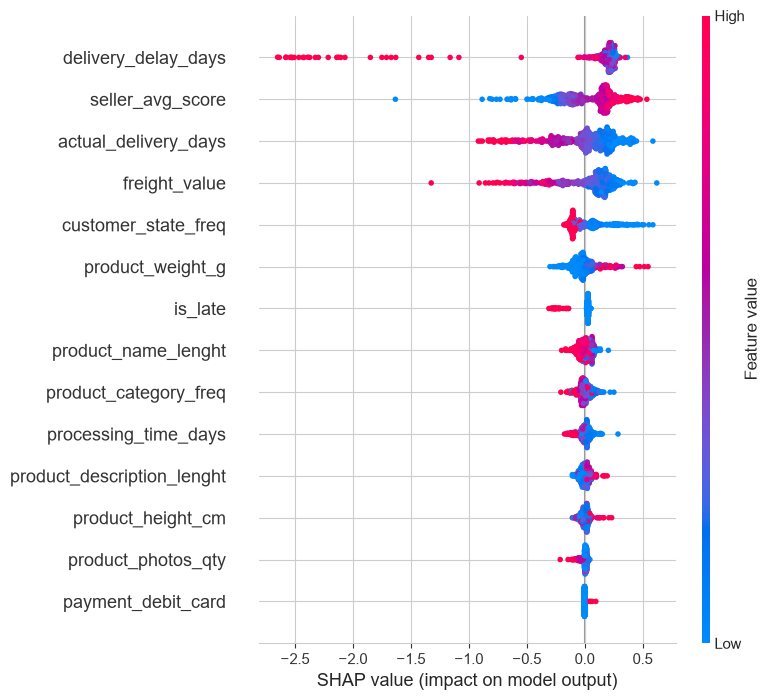

In [23]:
# global summary [1 mark]
# YOUR CODE HERE
shap.summary_plot(
    shap_values_plot,
    X_shap,
    feature_names=selected_features,
    show=True
)

Using a predicted-UNSATISFIED example (row 0)


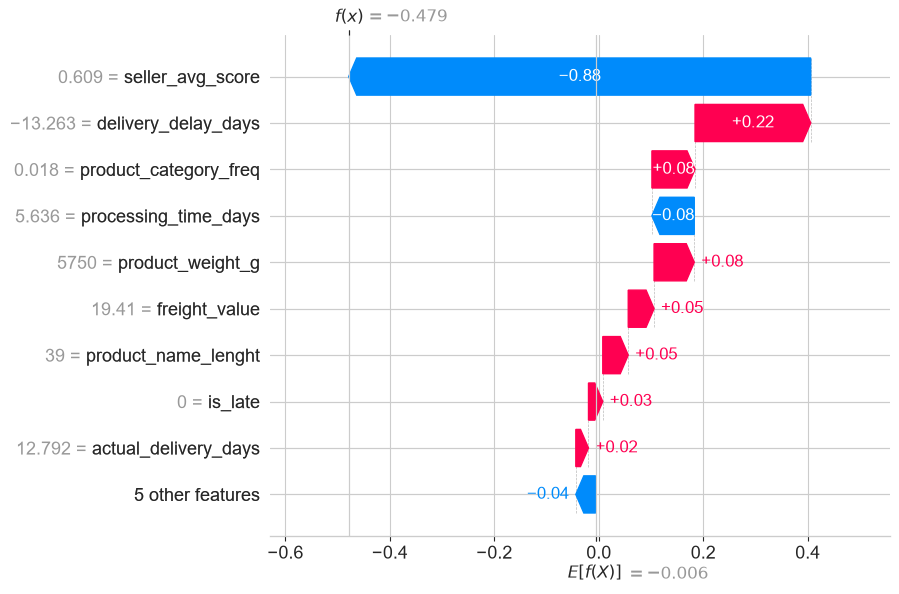

In [24]:
# local explanation for one order (a predicted-unsatisfied case if available) [1 mark]
# YOUR CODE HERE

# Use shap_values_plot if it exists (from the earlier list-check cell), else fall back to shap_values
sv = shap_values_plot if "shap_values_plot" in dir() else shap_values

# Predictions on the same 500-row SHAP sample, for picking an example
X_shap_preds = best_xgb_selected.predict(X_shap)

# Find a predicted-unsatisfied order if one exists in this sample
unsatisfied_idx = np.where(X_shap_preds == 0)[0]

if len(unsatisfied_idx) > 0:
    example_idx = unsatisfied_idx[0]
    print(f"Using a predicted-UNSATISFIED example (row {example_idx})")
else:
    example_idx = 0
    print("No predicted-unsatisfied example in this sample — using row 0 instead")

# Build a SHAP Explanation object manually (native method doesn't return one automatically)
example_explanation = shap.Explanation(
    values=sv[example_idx],
    base_values=base_value,
    data=X_shap.iloc[example_idx].values,
    feature_names=selected_features
)

shap.plots.waterfall(example_explanation, show=True)

LIME explanation (feature, weight):
  seller_avg_score <= 0.75: -0.0911
  -16.24 < delivery_delay_days <= -11.97: +0.0869
  product_weight_g > 1813.00: +0.0386
  is_late <= 0.00: +0.0322
  processing_time_days > 4.07: -0.0317
  17.16 < freight_value <= 24.04: +0.0315
  0.05 < customer_state_freq <= 0.13: +0.0298
  10.20 < actual_delivery_days <= 15.64: +0.0172
  payment_debit_card <= 0.00: -0.0169
  product_category_freq <= 0.03: +0.0118


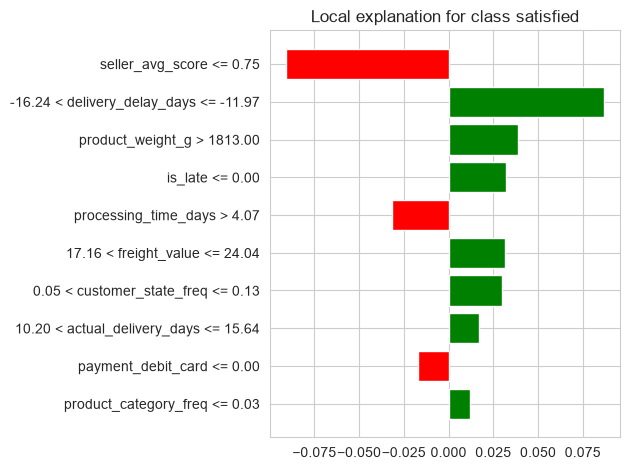

In [26]:
# ---- LIME example --- [1 mark]
# YOUR CODE HERE
from lime.lime_tabular import LimeTabularExplainer

# LIME reference data
lime_explainer = LimeTabularExplainer(
    training_data=X_cv[selected_features].values,
    feature_names=selected_features,
    class_names=["unsatisfied", "satisfied"],
    mode="classification",
    random_state=42
)

# Explain the same order used for SHAP
lime_exp = lime_explainer.explain_instance(
    data_row=X_shap.iloc[example_idx].values,
    predict_fn=best_xgb_selected.predict_proba,
    num_features=10
)

# Avoid show_in_notebook() — it hits a broken IPython import in this environment.
# Use plain outputs instead:
print("LIME explanation (feature, weight):")
for feature, weight in lime_exp.as_list():
    print(f"  {feature}: {weight:+.4f}")

# Also produces a matplotlib chart, which doesn't need the broken IPython.display path
fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

**Business mapping -** Translate the SHAP/LIME drivers into plain language for stakeholders:

| Driver (Model) | Business Meaning | Action |
|---|---|---|
| `delivery_delay_days`, `is_late` | How many days late (or early) an order arrives matters more than just whether it was late. The model relies mainly on delay length, not the simple late/on-time flag | Focus on cutting the size of delays, not just avoiding lateness altogether. |
| `actual_delivery_days`, `processing_time_days` | Slower processing and longer total delivery time hurt satisfaction even when an order isn't officially late. | Look at speeding up order processing before the item even ships |
| `freight_ratio` | 	Customers seem sensitive to shipping cost relative to order value. This feature didn't survive feature selection, but freight_value picked up a similar signal in the final model. | Review freight pricing for orders with high shipping cost relative to item price. |
| `seller_avg_score` | A seller's past satisfaction record can matter more than delivery itself — in one example, an order that arrived 13 days early was still predicted unsatisfied mainly because of a low seller score. | Track and support sellers whose average satisfaction sits below the platform average (~79%). |

### **Task 3.5 — Generate & Export Predictions [3 Marks]**
Use the optimised model to produce per-order predictions and probabilities, then export
`prediction_output.csv` with reporting-ready fields (order id, customer state, product category, delivery delay days, is late, actual satisfied, predicted satsified, prob. satisfied) for further analysis.

In [27]:
# YOUR CODE HERE
prediction_output = pd.DataFrame({
    "order_id": test_df["order_id"],
    "customer_state": test_df["customer_state"],
    "product_category": test_df["product_category_name_english"],
    "delivery_delay_days": test_df["delivery_delay_days"],
    "is_late": test_df["is_late"],
    "actual_satisfied": test_df["satisfied"],
    "predicted_satisfied": test_pred,
    "prob_satisfied": test_proba
})

print("Prediction output shape:", prediction_output.shape)
print("\nSample rows:")
display(prediction_output.head())

prediction_output.to_csv("prediction_output.csv", index=False)
print("\nSaved: prediction_output.csv")

Prediction output shape: (19165, 8)

Sample rows:


,order_id,customer_state,product_category,delivery_delay_days,is_late,actual_satisfied,predicted_satisfied,prob_satisfied
0,35011b1b3211ea7c58a699e4b8bfe93d,SP,housewares,-1.295162,0.0,1,0,0.481497
1,aa93e3c6d83d9d067dad35f632ad1b0e,RJ,perfumery,-14.565255,0.0,1,1,0.692044
2,cfa3e6925faeafb049f7bf5f1a133757,SP,furniture_mattress_and_upholstery,-14.084352,0.0,1,0,0.485531
3,ecbc00952c2d863b377c63a529282c5e,RJ,housewares,-10.293819,0.0,1,0,0.388955
4,f984f98a78a2beb0518a3d965cf1520d,MT,telephony,-20.005255,0.0,0,1,0.550328



Saved: prediction_output.csv


### **Comparative analysis summary (for the presentation and final report)**

WRITE YOUR TEXT HERE

Three advanced models were compared against the Stage 2 baseline. All three tree models outperformed Logistic Regression on F1-macro. Random Forest achieved the highest F1-macro, but showed substantial overfitting, with a training ROC-AUC of 1.00 compared with a CV ROC-AUC of 0.7070. XGBoost was therefore selected as the final model because it achieved the highest CV ROC-AUC of 0.7094 among the tree models, with a substantially smaller train–CV gap than Random Forest (0.1266 vs. 0.2930).

After hyperparameter tuning and feature selection, the number of features was reduced from 25 to 14. The final model achieved a test ROC-AUC of 0.7062, representing a +0.0143 improvement over the Stage 2 baseline of 0.6919. The improvement is modest but genuine.

SHAP identified delivery_delay_days as the most influential feature, followed by seller_avg_score and actual_delivery_days. This suggests that the magnitude of delivery delay provides more information to the model than simply whether an order is classified as late.

The local SHAP and LIME explanations provided complementary interpretations of the same order. Both highlighted seller reputation as an important negative contributor to that particular prediction. In this example, the order was approximately 13 days early but was still predicted as unsatisfied, largely because of the low seller score.

Overall, delivery performance and seller quality emerge as the two important business levers identified by the final model. The model provides a small but measurable improvement over the baseline, while SHAP and LIME make its predictions more interpretable and connect the model results to the patterns identified during earlier EDA.

---
## ✅ END-OF-NOTEBOOK CHECKLIST

> **⚠️ Verify every item before assembling the Stage 4 deliverables.**

- [ ] ≥ 3 advanced models trained (RandomForest, LightGBM, XGBoost) with imbalance handling
- [ ] One structured comparison table incl. the Stage 2 baseline
- [ ] **Stratified k-fold CV** used; bias–variance (train vs test) checked
- [ ] Final model selected **with justification**
- [ ] Hyperparameters tuned; feature selection applied; **improvement over baseline quantified**
- [ ] **SHAP** global + local explanations produced; **LIME** example shown; drivers mapped to business meaning
- [ ] **`model_comparison.csv`** and **`prediction_output.csv`** saved